### Loading JSON files and producing a combined plot

- load saved summary files
- combine summaries into 1 plot
- save final plot

In [1]:
# Imports for functionality
import json
import matplotlib.pyplot as plt

#### Experiment 1

In [9]:
paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\exp1results1_ts_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\exp1results2_psd_exp_matrix_cols_-1-2.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\exp1results3_specmod_exp_matrix_cols_-1-2.json",
]

results_combined = []

for p in paths:
    with open(p, "r") as f:
        results_combined.append(json.load(f))

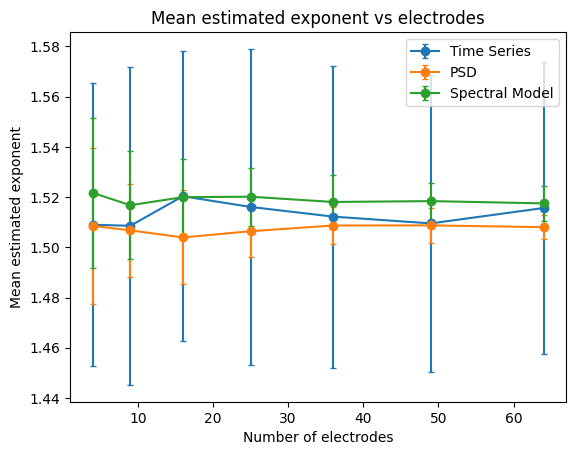

In [10]:
labels = ["Time Series", "PSD", "Spectral Model"]

fig, ax = plt.subplots()

for path, label in zip(paths, labels):

    with open(path, "r") as f:
        r = json.load(f)

    x = r["electrodes"]
    means = r["means"]
    yerr = r.get("stds", None)

    if yerr is not None:
        ax.errorbar(x, means, yerr=yerr, marker="o", capsize=2, label=label)

    else:
        ax.plot(x, means, marker="o", label=label)

ax.set_xlabel("Number of electrodes")
ax.set_ylabel("Mean estimated exponent")
ax.set_title("Mean estimated exponent vs electrodes")
ax.legend()
plt.show()

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\2D electrodes\Combined plots\exp1_combined_plot_2D_matrix_cols_-1-2.png", dpi=300, bbox_inches="tight")